Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/delhi_traffic_features.csv")

df.head()

,Trip_ID,start_area,end_area,distance_km,time_of_day,day_of_week,weather_condition,traffic_density_level,road_type,average_speed_kmph
0,TRIP_00001,Vasant Kunj,Kalkaji,9.44,Night,Weekday,Clear,Low,Main Road,37.8
1,TRIP_00002,Greater Kailash,Kalkaji,2.15,Night,Weekend,Clear,Low,Main Road,42.7
2,TRIP_00003,Janakpuri,Model Town,14.54,Morning Peak,Weekday,Rain,High,Inner Road,9.7
3,TRIP_00004,Punjabi Bagh,Dwarka,11.86,Night,Weekday,Clear,Low,Highway,68.5
4,TRIP_00005,Rohini,Chandni Chowk,20.26,Afternoon,Weekday,Fog,Medium,Highway,30.3


In [2]:
df.shape

(4000, 10)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_ID                4000 non-null   str    
 1   start_area             4000 non-null   str    
 2   end_area               4000 non-null   str    
 3   distance_km            4000 non-null   float64
 4   time_of_day            4000 non-null   str    
 5   day_of_week            4000 non-null   str    
 6   weather_condition      4000 non-null   str    
 7   traffic_density_level  4000 non-null   str    
 8   road_type              4000 non-null   str    
 9   average_speed_kmph     4000 non-null   float64
dtypes: float64(2), str(8)
memory usage: 312.6 KB


Missing Values Check

In [4]:
df.isnull().sum()

Trip_ID                  0
start_area               0
end_area                 0
distance_km              0
time_of_day              0
day_of_week              0
weather_condition        0
traffic_density_level    0
road_type                0
average_speed_kmph       0
dtype: int64

 Duplicate Check

In [6]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,distance_km,average_speed_kmph
count,4000.000000,4000.000000
mean,13.342965,28.085300
std,6.367559,17.057224
min,1.510000,4.800000
25%,8.660000,14.500000
50%,13.170000,24.200000
75%,17.230000,38.200000
max,33.010000,93.300000


 High traffic density is the most common traffic condition.

In [7]:
df['traffic_density_level'].value_counts()

traffic_density_level
High         1348
Medium       1055
Very High     979
Low           618
Name: count, dtype: int64

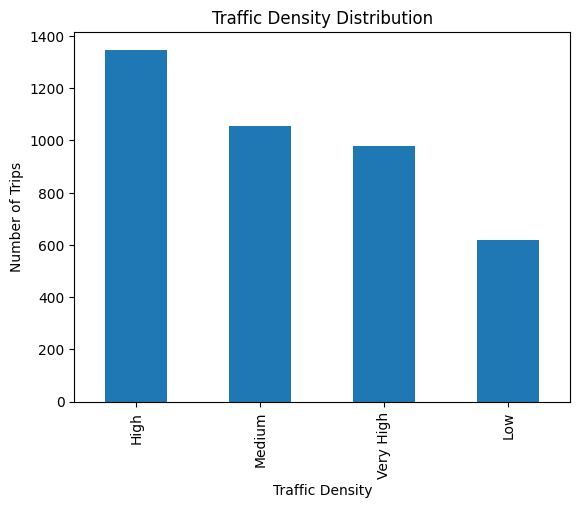

In [10]:
import matplotlib.pyplot as plt

df['traffic_density_level'].value_counts().plot(kind='bar')

plt.title("Traffic Density Distribution")
plt.xlabel("Traffic Density")
plt.ylabel("Number of Trips")

plt.show()

 Weather vs Traffic Density

In [11]:
pd.crosstab(
    df['weather_condition'],
    df['traffic_density_level']
)

traffic_density_level,High,Low,Medium,Very High
weather_condition,,,,
Clear,790,365,629,598
Fog,136,75,105,95
Heatwave,223,79,153,153
Rain,199,99,168,133


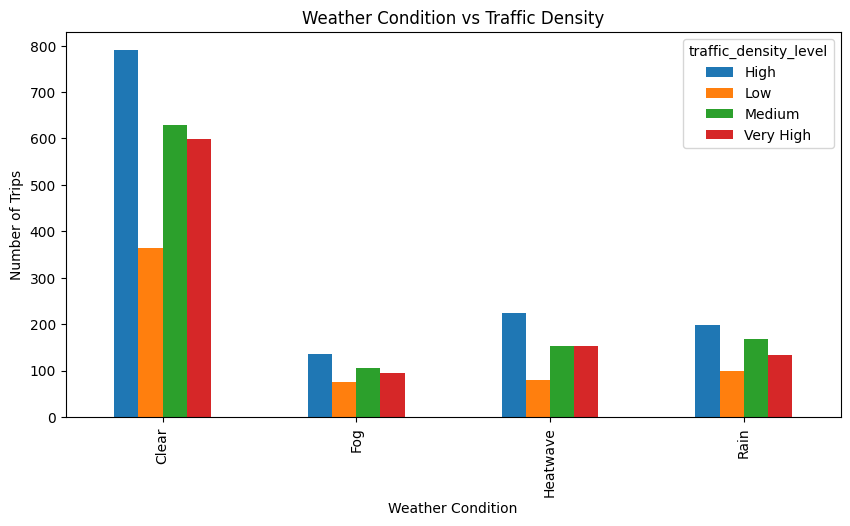

In [12]:
pd.crosstab(
    df['weather_condition'],
    df['traffic_density_level']
).plot(kind='bar', figsize=(10,5))

plt.title("Weather Condition vs Traffic Density")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Trips")
plt.show()

Time of Day vs Traffic Density

In [13]:
pd.crosstab(
    df['time_of_day'],
    df['traffic_density_level']
)

traffic_density_level,High,Low,Medium,Very High
time_of_day,,,,
Afternoon,309,201,467,80
Evening Peak,531,86,233,547
Morning Peak,470,100,234,346
Night,38,231,121,6


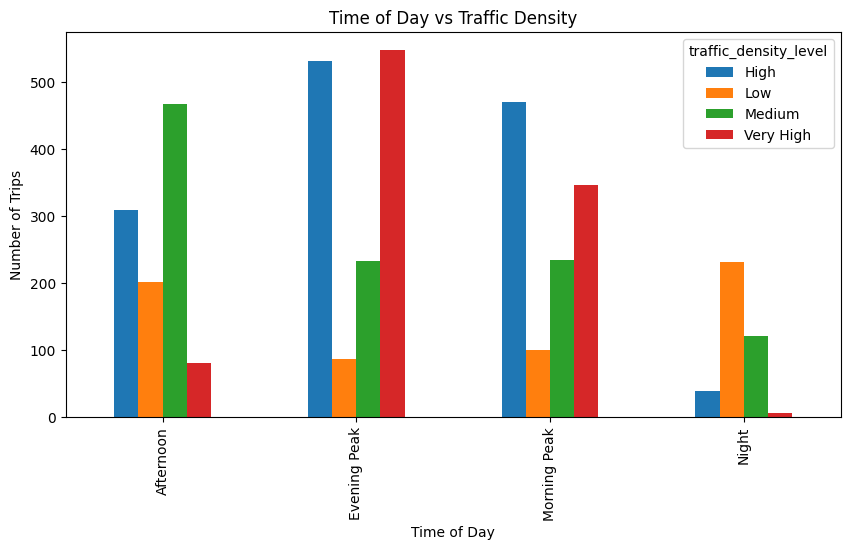

In [14]:
pd.crosstab(
    df['time_of_day'],
    df['traffic_density_level']
).plot(kind='bar', figsize=(10,5))

plt.title("Time of Day vs Traffic Density")
plt.xlabel("Time of Day")
plt.ylabel("Number of Trips")
plt.show()

 Road Type vs Traffic Density

In [15]:
pd.crosstab(
    df['road_type'],
    df['traffic_density_level']
)

traffic_density_level,High,Low,Medium,Very High
road_type,,,,
Highway,469,207,383,360
Inner Road,250,121,172,182
Main Road,629,290,500,437


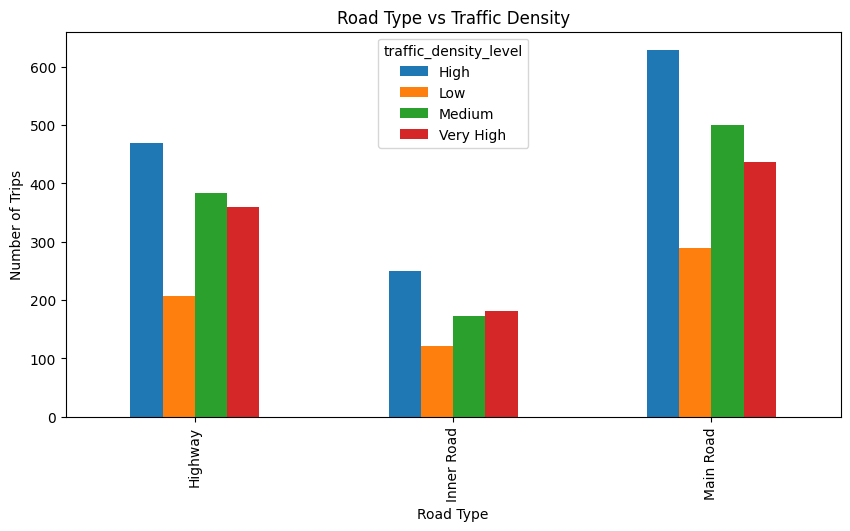

In [16]:
pd.crosstab(
    df['road_type'],
    df['traffic_density_level']
).plot(kind='bar', figsize=(10,5))

plt.title("Road Type vs Traffic Density")
plt.xlabel("Road Type")
plt.ylabel("Number of Trips")
plt.show()

Average Speed vs Traffic Density

In [17]:
df.groupby('traffic_density_level')['average_speed_kmph'].mean()

traffic_density_level
High         24.208012
Low          46.949515
Medium       36.535450
Very High    12.409704
Name: average_speed_kmph, dtype: float64

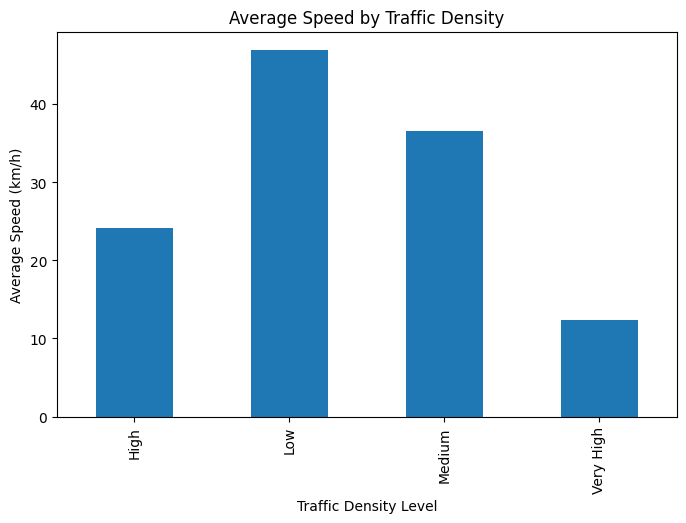

In [18]:
df.groupby('traffic_density_level')['average_speed_kmph'].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Speed by Traffic Density")
plt.xlabel("Traffic Density Level")
plt.ylabel("Average Speed (km/h)")
plt.show()

Average Speed by Road Type

In [19]:
df.groupby('road_type')['average_speed_kmph'].mean()

road_type
Highway       39.064693
Inner Road    14.645931
Main Road     24.940787
Name: average_speed_kmph, dtype: float64

# Machine Learning Model

## Traffic Density Prediction using Random Forest

In [20]:
df.columns

Index(['Trip_ID', 'start_area', 'end_area', 'distance_km', 'time_of_day',
       'day_of_week', 'weather_condition', 'traffic_density_level',
       'road_type', 'average_speed_kmph'],
      dtype='str')

In [21]:
X = df[['distance_km',
        'time_of_day',
        'day_of_week',
        'weather_condition',
        'road_type',
        'average_speed_kmph']]

y = df['traffic_density_level']

In [22]:
from sklearn.preprocessing import LabelEncoder

le_time = LabelEncoder()
le_day = LabelEncoder()
le_weather = LabelEncoder()
le_road = LabelEncoder()
le_target = LabelEncoder()

X['time_of_day'] = le_time.fit_transform(X['time_of_day'])
X['day_of_week'] = le_day.fit_transform(X['day_of_week'])
X['weather_condition'] = le_weather.fit_transform(X['weather_condition'])
X['road_type'] = le_road.fit_transform(X['road_type'])

y = le_target.fit_transform(y)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.83125


## Model Performance

The Random Forest Classifier achieved an accuracy of 83.13% in predicting traffic density levels.

This indicates that the model is able to successfully classify traffic conditions based on factors such as distance, weather, road type, time of day, and average vehicle speed.

In [27]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
5  average_speed_kmph    0.526476
0         distance_km    0.168591
4           road_type    0.108947
1         time_of_day    0.090240
3   weather_condition    0.083140
2         day_of_week    0.022606


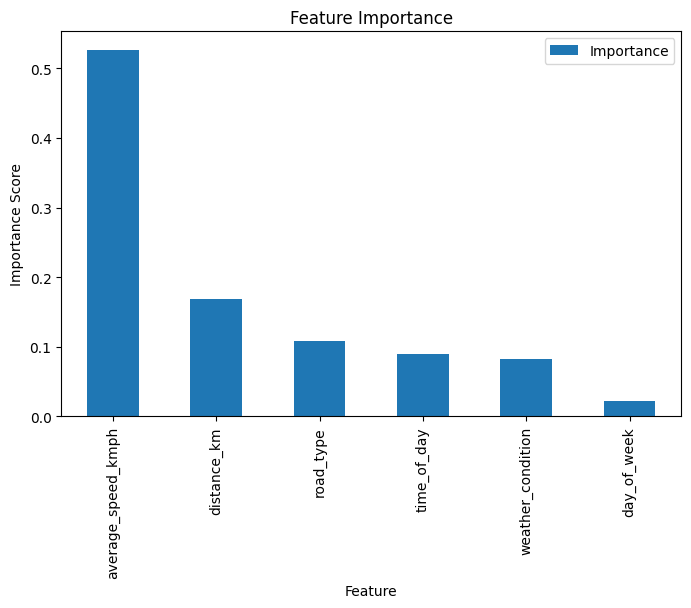

In [28]:
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()